# Expression analysis SHMss events (CLL/MBL)

In [1]:
# Load packages
options(warn = -1)
library("IRdisplay")
library(tidyverse)
library(Seurat)
library(ggh4x)
library(data.table)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.2     ✔ readr     2.1.4
✔ forcats   1.0.0     ✔ stringr   1.5.0
✔ ggplot2   3.5.1     ✔ tibble    3.2.1
✔ lubridate 1.9.2     ✔ tidyr     1.3.0
✔ purrr     1.0.1     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
The legacy packages maptools, rgdal, and rgeos, underpinning the sp package,
which was just loaded, will retire in October 2023.
Please refer to R-spatial evolution reports for details, especially
https://r-spatial.org/r/2023/05/15/evolution4.html.
It may be desirable to make the sf package available;
package maintainers should consider adding sf to Suggests:.
The sp package is now running under evolution status 2
     (status 2 uses the sf package in place of rgdal)

Att

In [2]:
suppressMessages(source("code/functions.R"))

## Load data

### Load input data (all sequences)

In [4]:
df_seq <- Sys.glob("input/output_shm_v4/MBL/consensus/*/*.csv") %>% 
  purrr::map_dfr(function(x) { 
    readr::read_csv(x, col_types = "ccinnccc", progress = FALSE) %>% 
      dplyr::mutate(subject = gsub("^.*/|.csv*$", "", x)) %>% 
      filter(ref_vdj_coverage == 1.0) 
  }) 

### Load list of cells with complete VDJ

In [5]:
df_complete_cells <- read.csv("input/complete_cells_MBL.csv")

### Load all SHMss events detected (positive + false positive)

In [6]:
# load data
df <- Sys.glob("input/shm_incl_po_subrg.20210912/CLLMBL/*/*.csv") %>%
  purrr::map_dfr(function(x) {
    readr::read_csv(x, col_types = "ccicccilciicc", progress = FALSE) %>%
      dplyr::mutate(subject = gsub("^.*/|\\.shm.*$", "", x))
  })

### Load df with filtered SHMss events (trully positive)

In [7]:
df_summary <- read.csv("output/df_summary_CLL_MBL_v1.csv")
head(df_summary)

subject,cell,vgene_position_aligned,nucl_po,context_po,subregion,variation,umis,productive
<lgl>,<lgl>,<lgl>,<lgl>,<lgl>,<lgl>,<lgl>,<lgl>,<lgl>


### Load expression data normalized

In [8]:
# # read expression data (every experiment)
# Q1 <- Read10X(data.dir = paste0("~/repositories/MBL_10X/110_CellRanger_analysis.freeze01/Q1/GEX/outs/raw_feature_bc_matrix/")) %>%
#   CreateSeuratObject(project = "Q1", min.cells = 3, min.features = 200)  %>% 
#                 SCTransform( return.only.var.genes = FALSE )

# Q2 <- Read10X(data.dir = paste0("~/repositories/MBL_10X/110_CellRanger_analysis.freeze01/Q2/GEX/outs/raw_feature_bc_matrix/")) %>%
#   CreateSeuratObject(project = "Q2", min.cells = 3, min.features = 200)  %>% 
#                 SCTransform( return.only.var.genes = FALSE )

In [9]:
# saveRDS( Q1, "output/Q1_SCT.rds")
# saveRDS( Q2, "output/Q2_SCT.rds")

In [10]:
# # compbined the 3 experiments
# CLL_combined_norm <- merge(Q1, y = c(Q2), add.cell.ids = c("Q1", "Q2"), project = "CLL/MBL")
# CLL_combined_norm

In [11]:
# # save merge object
# saveRDS(CLL_combined_norm, "output/CLL_MBL_merge.rds")

In [12]:
#CLL_combined_norm <- readRDS("output/CLL_MBL_merge.rds")

### Integrate 8 dataset and remove batch effect

**Tips for integrating large datasets**
https://satijalab.org/seurat/articles/integration_large_datasets.html

- For very large datasets, the standard integration workflow can sometimes be prohibitively computationally expensive. In this workflow, we employ two options that can improve efficiency and runtimes:

1. Reciprocal PCA (RPCA)
2. Reference-based integration (I did not do this one)

- This alternative workflow consists of the following steps:

1. Create a list of Seurat objects to integrate
2. Perform normalization, feature selection, and scaling separately for each dataset
3. Run PCA on each object in the list
4. Integrate datasets, and proceed with joint analysis

In [7]:
# # read expression data (every experiment)
# Q1 <- Read10X(data.dir = paste0("~/repositories/MBL_10X/110_CellRanger_analysis.freeze01/Q1/GEX/outs/raw_feature_bc_matrix/")) %>%
#   CreateSeuratObject(project = "Q1", min.cells = 3, min.features = 200)   
              

# Q2 <- Read10X(data.dir = paste0("~/repositories/MBL_10X/110_CellRanger_analysis.freeze01/Q2/GEX/outs/raw_feature_bc_matrix/")) %>%
#   CreateSeuratObject(project = "Q2", min.cells = 3, min.features = 200)  

In [8]:
# saveRDS( Q1, "output/Q1.rds")
# saveRDS( Q2, "output/Q2.rds")

In [30]:
# # merge in a list
# l <-
#   list(Q1, Q2)

**first perform standard normalization and variable feature selection** We use seurat object without SCT transformation

In [31]:
# l <- lapply(X = l, FUN = function(x) {
#     x <- NormalizeData(x, verbose = FALSE)
#     x <- FindVariableFeatures(x, verbose = FALSE)
# })

**Next, select features for downstream integration, and run PCA on each object in the list, which is required for running the alternative reciprocal PCA workflow**

In [32]:
# features <-   SelectIntegrationFeatures( object.list = l, nfeatures = 3500 ) %>% 
#     as.data.frame() %>% 
#     dplyr::rename( geneName = "." ) %>% 
#     filter( !geneName %like% "^RPL",
#             !geneName %like% "^RPS",
#             !geneName %like% "^MT-" ) %>% 
#     slice_head( n = 3000 ) %>% 
#   pull( geneName )
# l <- lapply(X = l, FUN = function(x) {
#     x <- ScaleData(x, features = features, verbose = FALSE)
#     x <- RunPCA(x, features = features, verbose = FALSE)
# })

15:58:45 UMAP embedding parameters a = 0.9922 b = 1.112

15:58:45 Read 8467 rows and found 50 numeric columns

15:58:45 Using Annoy for neighbor search, n_neighbors = 30

15:58:45 Building Annoy index with metric = cosine, n_trees = 50

0%   10   20   30   40   50   60   70   80   90   100%

[----|----|----|----|----|----|----|----|----|----|

*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
|

15:58:47 Writing NN index file to temp file /var/folders/_y/9gg2ckqx641_1cl14gn22tk80000gn/T//RtmpTvoqcs/file3a8071c036f7

15:58:47 Searching Annoy index using 1 thread, search_k = 3000

15:58:49 Annoy recall = 100%

15:58:50 Commencing smooth kNN distance calibration using 1 thread
 with target n_neighbors = 30

15:58:51 Initializing from normalized Laplacian + noise (using irlba)

15:58:52 Commencing optimization for 500 epochs, with 393236 positive edges

15:59:05 Optimization finished

15:59:20 UMAP embedding parameters a = 0.9922 b = 1.112

15:59:20 Read 8480 rows and found 50 numeric columns

15:59:20 Using Annoy for neighbor search, n_neighbors = 30

15:59:20 Building Annoy index with metric = cosine, n_trees = 50

0%   10   20   30   40   50   60   70   80   90   100%

[----|----|----|----|----|----|----|----|----|----|

*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
|

15:59:21 Writing NN index file to temp file /var/folders/_y/9gg2ckqx641_1cl14gn22tk80000gn/T//RtmpTvoqcs/file3a80258cc79

15:59:21 Searching Annoy index using 1 thread, search_k = 3000

15:59:23 Annoy recall = 100%

15:59:24 Commencing smooth kNN distance calibration using 1 thread
 with target n_neighbors = 30

15:59:24 Initializing from normalized Laplacian + noise (using irlba)

15:59:25 Commencing optimization for 500 epochs, with 377284 positive edges

15:59:43 Optimization finished


**The main efficiency improvements are gained in FindIntegrationAnchors(). First, we use reciprocal PCA (RPCA) instead of CCA, to identify an effective space in which to find anchors.
When determining anchors between any two datasets using reciprocal PCA, we project each dataset into the others PCA space and constrain the anchors by the same mutual neighborhood requirement. All downstream integration steps remain the same and we are able to ‘correct’ (or harmonize) the datasets.**

In [13]:
# anchors <- FindIntegrationAnchors(object.list = l, reduction = "rpca", #all pairwise anchors are found
#     dims = 1:50)

Computing 2000 integration features

Scaling features for provided objects

Computing within dataset neighborhoods

Finding all pairwise anchors

Projecting new data onto SVD

Projecting new data onto SVD

Finding neighborhoods

Finding anchors

	Found 1033 anchors


**Integrate data and save data**

In [14]:
# CLL.integrated <- IntegrateData(anchorset = anchors, dims = 1:50)


Merging dataset 1 into 2

Extracting anchors for merged samples

Finding integration vectors

Finding integration vector weights

Integrating data

In [ ]:
# CLL.integrated <- ScaleData(CLL.integrated, verbose = FALSE)
# CLL.integrated <- RunPCA(CLL.integrated, verbose = FALSE)
# CLL.integrated <- RunUMAP(CLL.integrated, dims = 1:50)

16:42:53 UMAP embedding parameters a = 0.9922 b = 1.112

16:42:54 Read 16947 rows and found 50 numeric columns

16:42:54 Using Annoy for neighbor search, n_neighbors = 30

16:42:54 Building Annoy index with metric = cosine, n_trees = 50

0%   10   20   30   40   50   60   70   80   90   100%

[----|----|----|----|----|----|----|----|----|----|

*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
|

16:42:57 Writing NN index file to temp file /var/folders/_y/9gg2ckqx641_1cl14gn22tk80000gn/T//RtmpTvoqcs/file3a805160ef02

16:42:57 Searching Annoy index using 1 thread, search_k = 3000

16:43:05 Annoy recall = 100%

16:43:06 Commencing smooth kNN distance calibration using 1 thread
 with target n_neighbors = 30

16:43:07 Initializing from normalized Laplacian + noise (using irlba)

16:43:10 Commencing optimization for 200 epochs, with 774184 positive edges

16:43:35 Optimization finished


In [44]:
# #save integrated object
# saveRDS(CLL.integrated, "output/Q12_integrated.rds")

### List of genes

In [8]:
filename <- "input/names_genes_dna_repair.csv"
genes_names <- read.csv(filename)

In [9]:
# number of genes analysed
length(genes_names$gene)

[1] 66

### **UMAP ploting**

In [4]:
#read integrated object
CLL.integrated  <- readRDS("output/Q12_integrated.rds")

#### Excercise machine learning course

In [49]:
xx <- CLL.integrated@assays$integrated@scale.data %>%
       as.data.frame() %>%
  rownames_to_column(var = "gene") %>%
  filter(!str_detect(gene, "^IG")) %>%
  column_to_rownames(var = "gene") %>%
  t() %>%
  as.data.frame() %>%
  rownames_to_column(var = "cell")

In [50]:
xy <- xx %>% left_join(id, by = c("cell" = "cellbarcode")) %>% filter(!subject == "NA") %>% select(-vireoCluster) %>%	
      mutate(diagnosis = str_extract(subject, "(?<=_)[^_]+$"))

In [51]:
write.csv(xy, "output/CLL_MBL_scaled.csv", row.names=FALSE)

In [36]:
# load clustaer information df and select subject and cluster 
subject_def <- read.csv("input/cell_source_subject.vireo_hla.20200409.tsv", sep="") 
id <- subject_def %>%
      mutate(cellbarcode = str_remove(cell, "^.{3}"), cellbarcode = paste0(cellbarcode,"_",(gsub("Q(\\d+).*", "\\1", source)))) %>%
      mutate(vireoCluster=str_replace(vireoCluster, ":", "_")) %>%
    mutate(subject = case_when(
    vireoCluster == "Q1_fm1" ~ "S5001_Donor",
    vireoCluster == "Q1_fm2" ~ "S10007_Donor",
    vireoCluster == "Q1_mm4" ~ "S5048_Donor",
    vireoCluster == "Q1_mm5" ~ "S5714_CLL",
    vireoCluster == "Q1_fm3" ~ "S7482_CLL",
    vireoCluster == "Q1_mx6" ~ "S9121_MBL",
    vireoCluster == "Q2_fm1" ~ "S4725_CLL",
    vireoCluster == "Q2_fm2" ~ "S9856_CLL",
    vireoCluster == "Q2_mm4" ~ "S356_CLL",
    vireoCluster == "Q2_mm5" ~ "S5530_Donor",
    vireoCluster == "Q2_fm3" ~ "S7580_Donor",
    vireoCluster == "Q2_xf7" ~ "S9534_MBL",
    TRUE ~ "NA")) %>% select(source, cellbarcode, subject,vireoCluster)

In [37]:
head(id)

,source,cellbarcode,subject,vireoCluster
,<chr>,<chr>,<chr>,<chr>
1,Q1,AAACCTGAGCGATAGC-1_1,S5001_Donor,Q1_fm1
2,Q1,AAACCTGAGCTAGTGG-1_1,S5001_Donor,Q1_fm1
3,Q1,AAACCTGCAAATACAG-1_1,S10007_Donor,Q1_fm2
4,Q1,AAACCTGCAATTGCTG-1_1,NA,NA
5,Q1,AAACCTGCATCCTAGA-1_1,S5048_Donor,Q1_mm4
6,Q1,AAACCTGCATGACATC-1_1,S5714_CLL,Q1_mm5


In [8]:
id %>% pull(source) %>% table()

.
  Q1   Q2 
8235 8298 

In [9]:
id_cll <- id %>% select(source,cellbarcode,subject)
write.csv(id_cll, "output/id_cell.csv", row.names=FALSE)

In [10]:
#extract metadata to obtain df with all cells
sample_metadata <- CLL.integrated@meta.data %>% rownames_to_column("cellbarcode") %>%
                    left_join(id, by=c("cellbarcode", "orig.ident" = "source")) %>%
              select(cellbarcode, subject, vireoCluster) %>% column_to_rownames(var="cellbarcode")

In [11]:
#cells lost
sample_metadata %>% pull(subject) %>%is.na() %>% sum()

[1] 422

In [12]:
# Add metadata to Seurat object
CLL.integrated <- AddMetaData(object = CLL.integrated, metadata = sample_metadata)

In [13]:
head(CLL.integrated@meta.data )

,orig.ident,nCount_RNA,nFeature_RNA,subject,vireoCluster
,<chr>,<dbl>,<int>,<chr>,<chr>
AAACCTGAGCGATAGC-1_1,Q1,939,430,S5001_Donor,Q1_fm1
AAACCTGAGCTAGTGG-1_1,Q1,2375,959,S5001_Donor,Q1_fm1
AAACCTGCAAATACAG-1_1,Q1,1452,493,S10007_Donor,Q1_fm2
AAACCTGCAATTGCTG-1_1,Q1,683,281,NA,NA
AAACCTGCATCCTAGA-1_1,Q1,1549,523,S5048_Donor,Q1_mm4
AAACCTGCATGACATC-1_1,Q1,2399,806,S5714_CLL,Q1_mm5


In [59]:
# Extract the t-SNE coordinates from the integrated Seurat object
tsne_coordinates <- CLL.integrated@reductions$umap@cell.embeddings

# Create a data frame with the t-SNE coordinates and cluster information
umap_df <- data.frame(x = tsne_coordinates[, 1], y = tsne_coordinates[, 2],
                      cluster = CLL.integrated@meta.data$orig.ident,
                     subject = CLL.integrated@meta.data$subject)
umap_df <- umap_df %>% rownames_to_column("cellbarcode") #%>% left_join(cellSubject_k123B, by=c("cellbarcode","cluster")) %>% filter(!is.na(subject)) # we lose ~8000 cells not defined

head(umap_df)

,cellbarcode,x,y,cluster,subject
,<chr>,<dbl>,<dbl>,<chr>,<chr>
1,AAACCTGAGCGATAGC-1_1,6.687863,0.8821876,Q1,S5001_Donor
2,AAACCTGAGCTAGTGG-1_1,3.422667,-2.8069021,Q1,S5001_Donor
3,AAACCTGCAAATACAG-1_1,8.457102,-4.9367758,Q1,S10007_Donor
4,AAACCTGCAATTGCTG-1_1,-2.986375,-4.9386345,Q1,NA
5,AAACCTGCATCCTAGA-1_1,7.513341,0.3783536,Q1,S5048_Donor
6,AAACCTGCATGACATC-1_1,-8.958419,-5.0231477,Q1,S5714_CLL


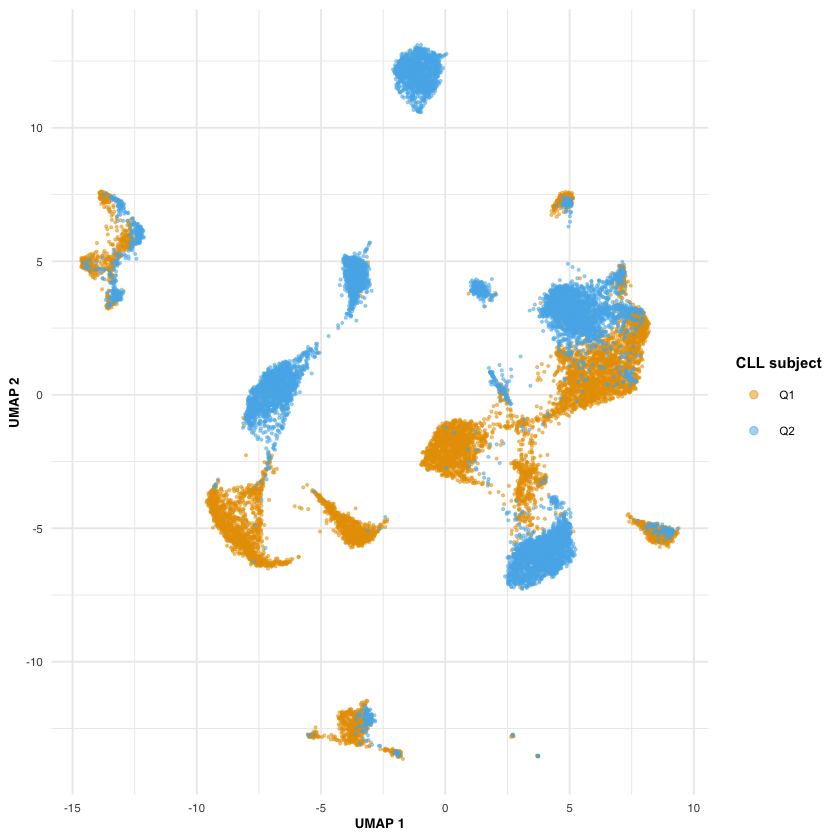

In [52]:
# plot umap + clusters

# # define colors for clusters and annotations
# cluster_colors <- c("#E41A1C", "#377EB8", "#4DAF4A","#E41A1C", "#377EB8", "#4DAF4A","#E41A1C", "#377EB8", "#4DAF4A")
# annotation_color <- "black"
colors <- c("#E69F00", "#56B4E9", "#009E73", "#F0E442", "#0072B2", "#D55E00", "#CC79A7", "#999999", "#8c6bb1", "#d01c8b", "#e7298a", "#66a61e", "#ffeda0")
colors <- c("#E69F00", "#56B4E9", "#009E73", "#F0E442", "#0072B2",
                "#D55E00", "#CC79A7", "#4169E1", "#FFAABB", "#DDCC77",
                "#22AA99", "#99DDFF", "#AA4499")

umap_plot <- ggplot( umap_df, aes( x, y,color = cluster ) ) +
  geom_point(size = 0.5, alpha = 0.5) +
  # geom_point( data = umap_df %>%
  #               filter( annotation == TRUE ),
              # aes( x, y ), color = "black",size = 1) +
 scale_color_manual(values = colors,name = "CLL subject") +
 theme_minimal() +
 labs(x = "UMAP 1", y = "UMAP 2") +
  theme(
    legend.title = element_text(size = 9, face = "bold"),
    legend.text = element_text(size = 7),
    legend.key.size = unit(1.5, "lines"),
    axis.title = element_text(size = 8, face = "bold", family = "sans"),
    axis.text = element_text(size = 7, family = "sans"),
    plot.title = element_text(size = 10, face = "bold", family = "sans"),
    legend.key = element_rect(color = NA)
  )+
  guides(color = guide_legend(override.aes = list(size=2))) 

umap_plot

In [53]:
fig_save(umap_plot, filename = "figs_paper/UMAP_subject_CLL", formats = c("pdf", "png"), width = 15, height = 12, units = "cm", dpi = 320)

In [61]:
CLL_samples <-  c("S5714_CLL","S7482_CLL","S4725_CLL","S9856_CLL","S356_CLL")

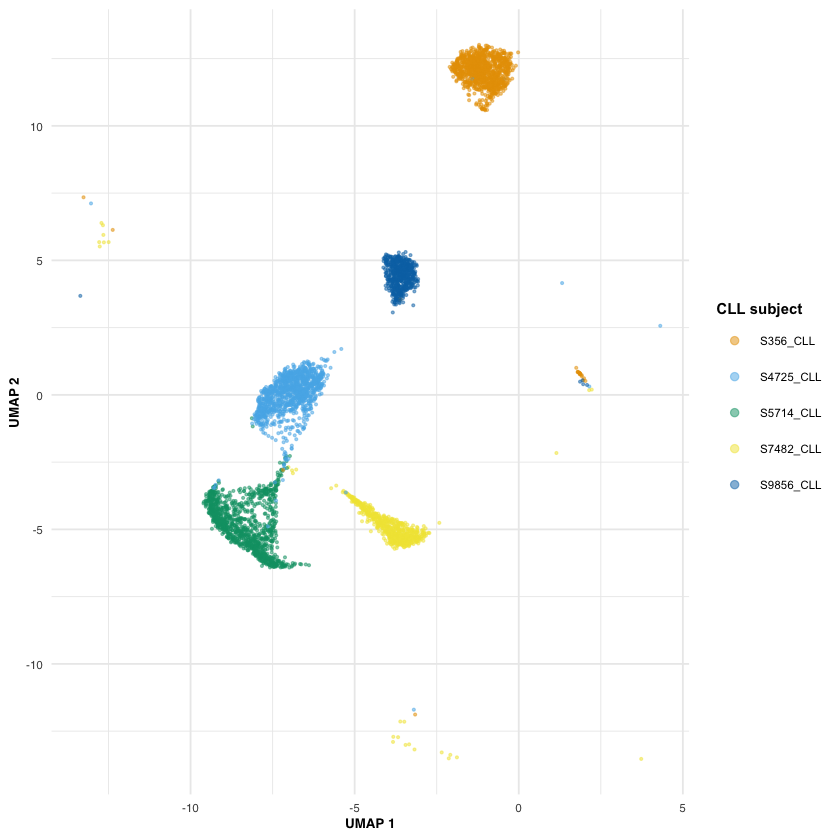

In [63]:
# plot umap + clusters

# # define colors for clusters and annotations
# cluster_colors <- c("#E41A1C", "#377EB8", "#4DAF4A","#E41A1C", "#377EB8", "#4DAF4A","#E41A1C", "#377EB8", "#4DAF4A")
# annotation_color <- "black"
colors <- c("#E69F00", "#56B4E9", "#009E73", "#F0E442", "#0072B2", "#D55E00", "#CC79A7", "#999999", "#8c6bb1", "#d01c8b", "#e7298a", "#66a61e", "#ffeda0")
colors <- c("#E69F00", "#56B4E9", "#009E73", "#F0E442", "#0072B2",
                "#D55E00", "#CC79A7", "#4169E1", "#FFAABB", "#DDCC77",
                "#22AA99", "#99DDFF", "#AA4499")

umap_plot <- ggplot( umap_df %>% filter(subject %in% CLL_samples), aes( x, y,color = subject ) ) +
  geom_point(size = 0.5, alpha = 0.5) +
  # geom_point( data = umap_df %>%
  #               filter( annotation == TRUE ),
              # aes( x, y ), color = "black",size = 1) +
 scale_color_manual(values = colors,name = "CLL subject") +
 theme_minimal() +
 labs(x = "UMAP 1", y = "UMAP 2") +
  theme(
    legend.title = element_text(size = 9, face = "bold"),
    legend.text = element_text(size = 7),
    legend.key.size = unit(1.5, "lines"),
    axis.title = element_text(size = 8, face = "bold", family = "sans"),
    axis.text = element_text(size = 7, family = "sans"),
    plot.title = element_text(size = 10, face = "bold", family = "sans"),
    legend.key = element_rect(color = NA)
  )+
  guides(color = guide_legend(override.aes = list(size=2))) 

umap_plot

In [ ]:
fig_save(umap_plot, filename = "figs_paper/UMAP_subject_CLL", formats = c("pdf", "png"), width = 15, height = 12, units = "cm", dpi = 320)

## Analysis with non normalized data

In [16]:
# filter only the GEX for the list of genes
dd <- CLL_combined@assays$RNA@counts %>%
  as.data.frame() %>%
  rownames_to_column(var = "gene") %>%
  filter(gene %in% genes_names$gene) %>%
  column_to_rownames(var = "gene") %>%
  t() %>%
  as.data.frame() %>%
  rownames_to_column(var = "cell")

head(dd)

,cell,RPA2,MUTYH,ADAR,FAM72A,PARP1,EXO1,MSH2,MSH6,APLF,⋯,NTHL1,RPA1,LIG3,PCNA,CHAF1A,XRCC1,LIG1,PNKP,POLD1,CHAF1B
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,Q1_AAACCTGAGCGATAGC-1,0,0,0,0,0,0,0,0,0,⋯,0,0,0,1,0,0,0,1,0,0
2,Q1_AAACCTGAGCTAGTGG-1,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
3,Q1_AAACCTGCAAATACAG-1,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
4,Q1_AAACCTGCAATTGCTG-1,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
5,Q1_AAACCTGCATCCTAGA-1,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
6,Q1_AAACCTGCATGACATC-1,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0


In [17]:
# clean df and include experiment column
pd <- dd %>%
  mutate(experiment = str_sub(cell, 1, 2)) %>% # str_extract("/\/$/", cell
  mutate(cell = gsub("^.{3}|.{2}$", "", cell)) # %>%
#       mutate(UNG_cat=ifelse(UNG == 0, "No", "Yes"))
head(pd)

,cell,RPA2,MUTYH,ADAR,FAM72A,PARP1,EXO1,MSH2,MSH6,APLF,⋯,RPA1,LIG3,PCNA,CHAF1A,XRCC1,LIG1,PNKP,POLD1,CHAF1B,experiment
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
1,AAACCTGAGCGATAGC,0,0,0,0,0,0,0,0,0,⋯,0,0,1,0,0,0,1,0,0,Q1
2,AAACCTGAGCTAGTGG,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,Q1
3,AAACCTGCAAATACAG,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,Q1
4,AAACCTGCAATTGCTG,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,Q1
5,AAACCTGCATCCTAGA,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,Q1
6,AAACCTGCATGACATC,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,Q1


In [18]:
# tranform values to categorical
pd_cat <- pd %>%
  mutate_if(is.numeric, ~ ifelse(. == 0, "No", "Yes"))
head(pd_cat)

,cell,RPA2,MUTYH,ADAR,FAM72A,PARP1,EXO1,MSH2,MSH6,APLF,⋯,RPA1,LIG3,PCNA,CHAF1A,XRCC1,LIG1,PNKP,POLD1,CHAF1B,experiment
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,⋯,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
1,AAACCTGAGCGATAGC,No,No,No,No,No,No,No,No,No,⋯,No,No,Yes,No,No,No,Yes,No,No,Q1
2,AAACCTGAGCTAGTGG,No,No,No,No,No,No,No,No,No,⋯,No,No,No,No,No,No,No,No,No,Q1
3,AAACCTGCAAATACAG,No,No,No,No,No,No,No,No,No,⋯,No,No,No,No,No,No,No,No,No,Q1
4,AAACCTGCAATTGCTG,No,No,No,No,No,No,No,No,No,⋯,No,No,No,No,No,No,No,No,No,Q1
5,AAACCTGCATCCTAGA,No,No,No,No,No,No,No,No,No,⋯,No,No,No,No,No,No,No,No,No,Q1
6,AAACCTGCATGACATC,No,No,No,No,No,No,No,No,No,⋯,No,No,No,No,No,No,No,No,No,Q1


In [19]:
# merge SHMss and expression data
cell_list <- df_summary %>%
  mutate(
    experiment = str_sub(subject, 1, 2),
    group = "SHMss_observed"
  ) %>%
  select(experiment, cell, group) %>%
  distinct() %>%
  right_join(pd_cat, by = c("cell", "experiment")) %>%
  mutate(group = ifelse(is.na(group), "SHMss_not_observed", "SHMss_observed"))

In [20]:
# remove incomplete cells and possible false positives
false_positives <- df %>%
  mutate(experiment = str_sub(subject, 1, 2), group = "SHMss_not_observed") %>%
  select(experiment, cell, group) %>%
  distinct()

cell_list <- cell_list %>%
  right_join(df_complete_cells) %>%
  anti_join(false_positives)

Joining, by = c("experiment", "cell")
Joining, by = c("experiment", "cell", "group")


In [21]:
# summarize data
shm_perc_sub <-  cell_list %>%
  gather(-subject, -experiment, -cell, -group, key = "gene", value = "expression") %>%
  select(-experiment, -cell) %>%
  group_by(subject, gene, group, expression) %>%
  summarise(count = n(), .groups="drop_last") %>%
  mutate(perc = count / sum(count) * 100) %>%
  left_join(genes_names, by = c("gene")) %>%
  mutate(group = factor(group, levels = c("SHMss_observed", "SHMss_not_observed"))) %>%
  arrange(subject, gene, group)

In [22]:
write.csv(shm_perc_sub, "output/shm_perc_sub_CLL.MBL.csv", row.names=FALSE)

In [23]:
head(shm_perc_sub)

subject,gene,group,expression,count,perc,pathway
<chr>,<chr>,<fct>,<chr>,<int>,<dbl>,<chr>
S356,ADAR,SHMss_not_observed,No,3,75,RNSA_editing
S356,ADAR,SHMss_not_observed,Yes,1,25,RNSA_editing
S356,AICDA,SHMss_not_observed,No,4,100,SHM
S356,APEX1,SHMss_not_observed,No,3,75,BER
S356,APEX1,SHMss_not_observed,Yes,1,25,BER
S356,APEX2,SHMss_not_observed,No,4,100,BER


In [24]:
# summarize data
shm_perc <- cell_list %>%
  gather(-subject, -experiment, -cell, -group, key = "gene", value = "expression") %>%
  select(-experiment, -cell) %>%
  group_by(gene, group, expression) %>%
  summarise(count = n(), .groups="drop_last") %>%
  mutate(perc = count / sum(count) * 100) %>%
  left_join(genes_names, by = c("gene")) %>%
  mutate(group = factor(group, levels = c("SHMss_observed", "SHMss_not_observed"))) %>%
  arrange( gene, group)

### AID expression analysis
**Fisher test**

In [25]:
shm_summary <- shm_perc %>%
  filter(gene == "AICDA") %>%
  group_by(group, expression) %>%
  summarise(counts = sum(count)) 

shm_summary

`summarise()` has grouped output by 'group'. You can override using the `.groups` argument.


group,expression,counts
<fct>,<chr>,<int>
SHMss_observed,No,3
SHMss_not_observed,No,146


In [26]:
shm_summary <- shm_perc %>%
  filter(gene == "AICDA") %>%
  group_by(group, expression) %>%
  summarise(counts = sum(count)) %>%
  spread(expression, counts) %>%
  column_to_rownames(var = "group")
shm_summary

`summarise()` has grouped output by 'group'. You can override using the `.groups` argument.


,No
,<int>
SHMss_observed,3
SHMss_not_observed,146


The Fisher’s exact test is used when there is at least one cell in the contingency table of the expected frequencies below 5. To retrieve the expected frequencies, use the chisq.test() function together with $expected:

In [27]:
chisq.test(shm_summary)$expected

[1] 74.5 74.5

In [28]:
shm_perc %>%
  filter(gene == "AICDA") %>%
  group_by(group, expression) # %>% summarise(count = sum(counts)) %>% mutate(Percentage= count * 100 / sum(count))

gene,group,expression,count,perc,pathway
<chr>,<fct>,<chr>,<int>,<dbl>,<chr>
AICDA,SHMss_observed,No,3,100,SHM
AICDA,SHMss_not_observed,No,146,100,SHM


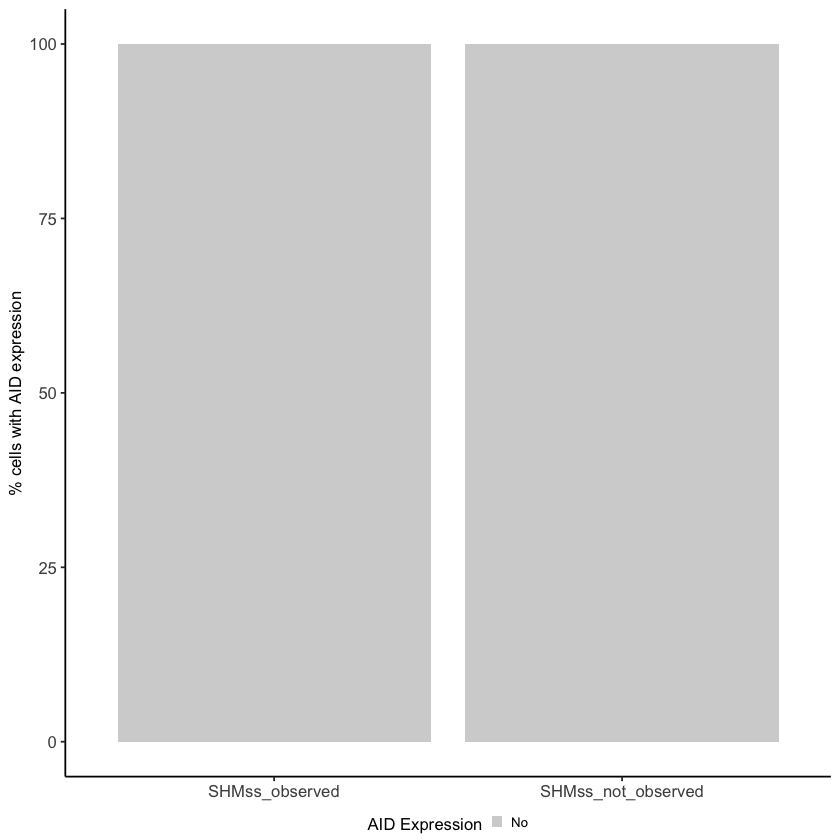

In [29]:
expre_summary <- ggplot(shm_perc %>% filter(gene == "AICDA") %>% group_by(group, expression), aes(x = group, y = perc, fill = expression)) +
  geom_bar(stat = "identity") +
  scale_fill_manual(values = c("#d3d3d3", "#ff8181"), name = "AID Expression", guide = guide_legend(reverse = TRUE)) +
  labs(x = "", y = "% cells with AID expression") +
  theme_classic() +
  scale_x_discrete(labels = c("neg_shm" = "SHMa not observed", "pos_shm" = "SHMa observed")) +
  theme(
    legend.position = "bottom", legend.margin = margin(t = -0.5, unit = "cm"),
    axis.text = element_text(size = 10, angle = 0),
    axis.title = element_text(size = 10),
    legend.title = element_text(size = 10), legend.text = element_text(size = 8), legend.key.size = unit(0.5, "line")
  )


fig_save(expre_summary, filename = "figs/FL/AID_expression_summary", formats = c("pdf", "png"), width = 10, height = 15, units = "cm", dpi = 320)
expre_summary

### DNA repair genes expression analysis

In [139]:
#define gene order for plotting
gene_order <- shm_perc %>% filter(group == "SHMss_not_observed", expression == "Yes") %>% arrange(-perc) %>% pull(gene) %>% unique()
gene_order

[1] "POLD4"  "HMGB1"  "MPG"    "MBD4"   "HMGB2"  "PARP1"  "POLE4"  "RPA3"  
 [9] "APEX1"  "RFC1"   "NUDT1"  "ADAR"   "PMS2"   "RPA2"   "POLE3"  "RFC4"  
[17] "POLD2"  "RECQL"  "PARP3"  "PMS1"   "RPA1"   "SMUG1"  "CHAF1A" "PARP4" 
[25] "PNKP"   "TDG"    "APEX2"  "MUTYH"  "POLB"   "POLD3"  "POLL"   "RFC2"  
[33] "APLF"   "APTX"   "FEN1"   "POLD1"  "UNG"    "XRCC1"  "LIG1"   "LIG3"  
[41] "MLH3"   "MSH3"   "MSH5"   "NTHL1"  "OGG1"   "RFC3"   "RFC5"

In [140]:
# change name of pathway
pathway.labs <- c('','BER','BER/MMR','MMR')
names(pathway.labs) <- c('SHM','BER','BER/MMR','MMR')

# change name of group
group.labs <- c("SHMss observed","SHMss not observed")
names(group.labs) <- c("SHMss_observed","SHMss_not_observed")

In [141]:
shm_perc_pub <- shm_perc %>% 
                 mutate(gene = factor(gene, levels = gene_order))  %>% 
                 filter(!gene %in% c("ADAR")) %>% 
                 mutate(pathway = factor(pathway, levels = c('SHM','BER','MMR','BER/MMR'))) %>%
                mutate(expression = case_when(
    (gene == "AICDA") & (expression == "No") ~ "F",
    (gene == "AICDA") & (expression == "Yes") ~ "T",
    TRUE ~ expression))

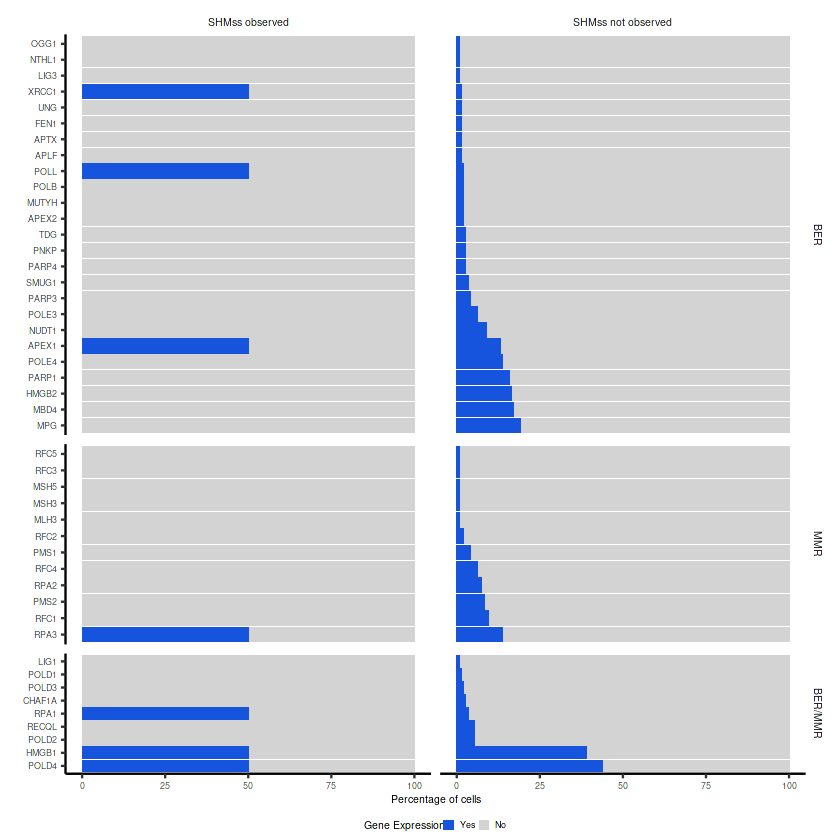

In [142]:
expre_summary <- ggplot(shm_perc_pub %>% filter(!is.na(gene)), aes(x = gene, y = perc, fill = expression)) +
  geom_bar(stat = "identity") +
  scale_fill_manual(values = c("#d3d3d3","#1654de","#d3d3d3","#3ec0a0"), name = "Gene Expression", guide = guide_legend(reverse = TRUE)) +
  labs(x = "", y = "Percentage of cells") +
  theme_classic() +
  scale_x_discrete(labels = c("neg_shm" = "SHMa not observed", "pos_shm" = "SHMa observed")) +
  theme(
    legend.position = "bottom", legend.margin = margin(t = -0.1, unit = "cm"),
    axis.text = element_text(size = 5, angle = 0),
    axis.title = element_text(size = 6),
    legend.title = element_text(size = 6), legend.text = element_text(size = 5), legend.key.size = unit(0.5, "line"),
    strip.text.x = element_text(size = 6),strip.text.y = element_text(size = 6), strip.background = element_blank()) +
  facet_grid(pathway ~ group, scales = "free", space = "free", labeller = labeller(group = group.labs)) +  #labeller = labeller(pathway = pathway.labs
  force_panelsizes(rows = c(1,0.5,0.3)) +
  coord_flip() #+
#  scale_x_discrete(expand = c(1, 0.5,0,0)) +



fig_save(expre_summary, filename = "figs/CLL_MBL/DNA_repair_expresion", formats = c("pdf", "png"), width = 7, height = 12, units = "cm", dpi = 320)
expre_summary

**Fisher exact test**

In [143]:
shm_summary_all <- shm_perc %>%
  filter(!gene %in% c("ADAR", "AICDA")) %>%
  group_by(gene,group, expression) %>%
  summarise(counts = sum(count)) %>%
   spread(expression, counts) %>%
   mutate(Yes = ifelse(is.na(Yes), 0, Yes)) %>%
   mutate(No = ifelse(is.na(No), 0, No)) %>%
   group_by(gene) %>%
   summarize(pvalue=fisher.test(matrix(c(Yes,No), nrow =2))$p.value)

shm_summary_all %>% filter(pvalue <0.05)

`summarise()` has grouped output by 'gene', 'group'. You can override using the `.groups` argument.



gene,pvalue
<chr>,<dbl>
PARP2,0.01351351
XRCC1,0.04026475


### DNA repair genes expression by range

In [144]:
# merge SHMss and expression data
cell_list <- df_summary %>%
  mutate(
    experiment = str_sub(subject, 1, 2),
    group = "SHMss_observed"
  ) %>%
  select(experiment, cell, group) %>%
  distinct() %>%
  right_join(pd, by = c("cell", "experiment")) %>%
  mutate(group = ifelse(is.na(group), "SHMss_not_observed", "SHMss_observed"))

In [145]:
# remove incomplete cells and possible false positives
false_positives <- df %>%
  mutate(experiment = str_sub(subject, 1, 2), group = "SHMss_not_observed") %>%
  select(experiment, cell, group) %>%
  distinct()

cell_list <- cell_list %>%
  right_join(df_complete_cells) %>%
  anti_join(false_positives)

Joining, by = c("experiment", "cell")

Joining, by = c("experiment", "cell", "group")



#### Filter out MBL data

In [146]:
# summarize data
shm_perc_sub <-  cell_list %>% filter(!subject %in% c("S9121","S9534") ) %>%
  gather(-subject, -experiment, -cell, -group, key = "gene", value = "expression") %>%
  mutate(expression_cat = case_when(
     (expression > 3) & (expression < 11)  ~ "4-10",
     (expression >10)  ~ ">10",
     TRUE ~ as.character(expression))) %>%
  select(-experiment, -cell,-expression) %>%
  group_by( gene, group, expression_cat) %>%
  summarise(count = n(), .groups="drop_last") %>%
  mutate(perc = count / sum(count) * 100) %>%
  left_join(genes_names, by = c("gene")) %>%
  mutate(group = factor(group, levels = c("SHMss_observed", "SHMss_not_observed"))) %>%
  arrange( gene, group)

In [147]:
shm_perc_pub <- shm_perc_sub %>% 
                 mutate(gene = factor(gene, levels = gene_order))  %>% 
                 filter(!gene %in% c("ADAR")) %>% 
                 mutate(pathway = factor(pathway, levels = c('SHM','BER','MMR','BER/MMR'))) %>% 
                  mutate(expression_cat = factor(expression_cat, levels = c('0','1','2','3','4-10','>10'))) 
#                 mutate(expression = case_when(
#     (gene == "AICDA") & (expression == "No") ~ "F",
#     (gene == "AICDA") & (expression == "Yes") ~ "T",
#     TRUE ~ expression))

In [148]:
head(shm_perc_pub)

gene,group,expression_cat,count,perc,pathway
<fct>,<fct>,<fct>,<int>,<dbl>,<fct>
NA,SHMss_not_observed,0,133,100.000000,SHM
APEX1,SHMss_not_observed,0,115,86.466165,BER
APEX1,SHMss_not_observed,1,18,13.533835,BER
APEX2,SHMss_not_observed,0,130,97.744361,BER
APEX2,SHMss_not_observed,1,3,2.255639,BER
APLF,SHMss_not_observed,0,131,98.496241,BER


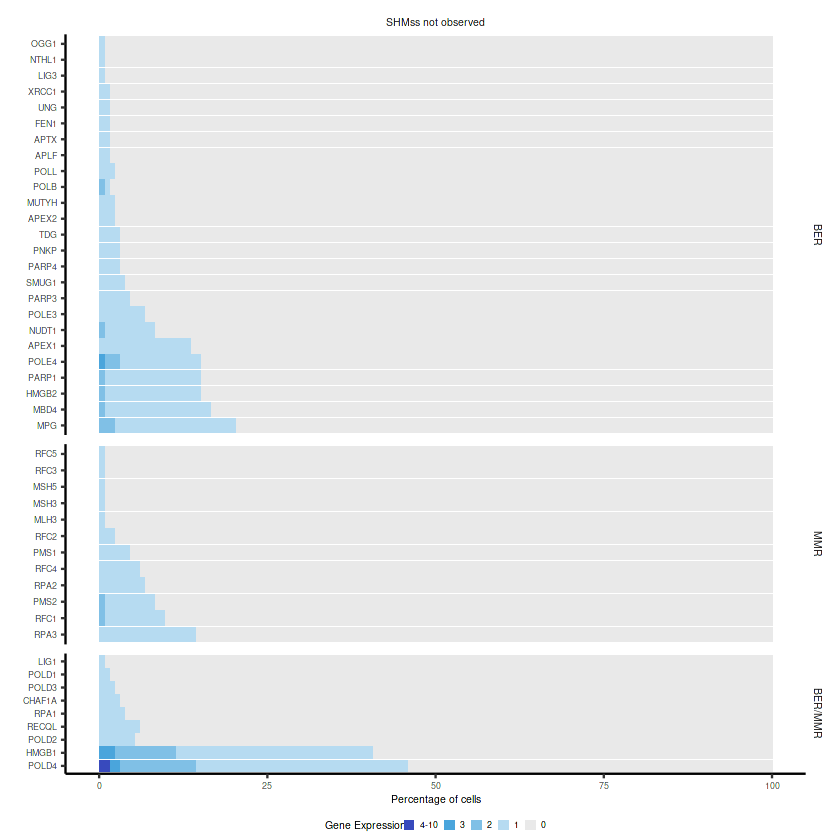

In [149]:
expre_summary <- ggplot(shm_perc_pub  %>% filter(!is.na(gene)), aes(x = gene, y = perc, fill = expression_cat)) +
  geom_bar(stat = "identity") +
#  scale_fill_manual(values = c("#d3d3d3","#B4617A","#1c9262","#384abd","#4aa5dc","#a09ece"), name = "Gene Expression", guide = guide_legend(reverse = TRUE)) +
  scale_fill_manual(values = c("#e9e9e9","#b6dbf1","#80c0e6","#4aa5dc","#384abd","#273384"), name = "Gene Expression", guide = guide_legend(reverse = TRUE)) +

  labs(x = "", y = "Percentage of cells") +
  theme_classic() +
  scale_x_discrete(labels = c("neg_shm" = "SHMa not observed", "pos_shm" = "SHMa observed")) +
  theme(
    legend.position = "bottom", legend.margin = margin(t = -0.1, unit = "cm"),
    axis.text = element_text(size = 5, angle = 0),
    axis.title = element_text(size = 6),
    legend.title = element_text(size = 6), legend.text = element_text(size = 5), legend.key.size = unit(0.5, "line"),
    strip.text.x = element_text(size = 6),strip.text.y = element_text(size = 6), strip.background = element_blank()) +
  facet_grid(pathway ~ group, scales = "free", space = "free", labeller = labeller(group = group.labs)) +  #labeller = labeller(pathway = pathway.labs
  force_panelsizes(rows = c(1,0.5,0.3)) +
  coord_flip() #+
#  scale_x_discrete(expand = c(1, 0.5,0,0)) +



fig_save(expre_summary, filename = "figs/FL/DNA_repair_expresion_norm", formats = c("pdf", "png"), width = 7, height = 12, units = "cm", dpi = 320)
expre_summary

In [150]:
shm_perc_pub_merge <- shm_perc_pub  %>% filter(!is.na(gene) , group == "SHMss_not_observed") %>%
mutate(diagnosis="CLL") 

write.csv(shm_perc_pub_merge, "output/shm_perc_sub_CLL_to_merge_no_norm.csv", row.names=FALSE)

### ADAR gene (RNA editing) expression analysis

**Fisher test**

In [151]:
shm_summary_adar <- shm_perc %>%
  filter(gene == "ADAR") %>%
  group_by(group, expression) %>%
  summarise(counts = sum(count)) %>%
  spread(expression, counts) %>%
  column_to_rownames(var = "group")
shm_summary_adar

`summarise()` has grouped output by 'group'. You can override using the `.groups` argument.



,No,Yes
,<int>,<int>
SHMss_observed,2,NA
SHMss_not_observed,134,12


The Fisher’s exact test is used when there is at least one cell in the contingency table of the expected frequencies below 5. To retrieve the expected frequencies, use the chisq.test() function together with $expected:

In [152]:
chisq.test(shm_summary)$expected

[1] 74 74

In [153]:
shm_perc %>%
  filter(gene == "ADAR") %>%
  group_by(group, expression) # %>% summarise(count = sum(counts)) %>% mutate(Percentage= count * 100 / sum(count))

gene,group,expression,count,perc,pathway
<chr>,<fct>,<chr>,<int>,<dbl>,<chr>
ADAR,SHMss_observed,No,2,100.000000,RNSA_editing
ADAR,SHMss_not_observed,No,134,91.780822,RNSA_editing
ADAR,SHMss_not_observed,Yes,12,8.219178,RNSA_editing


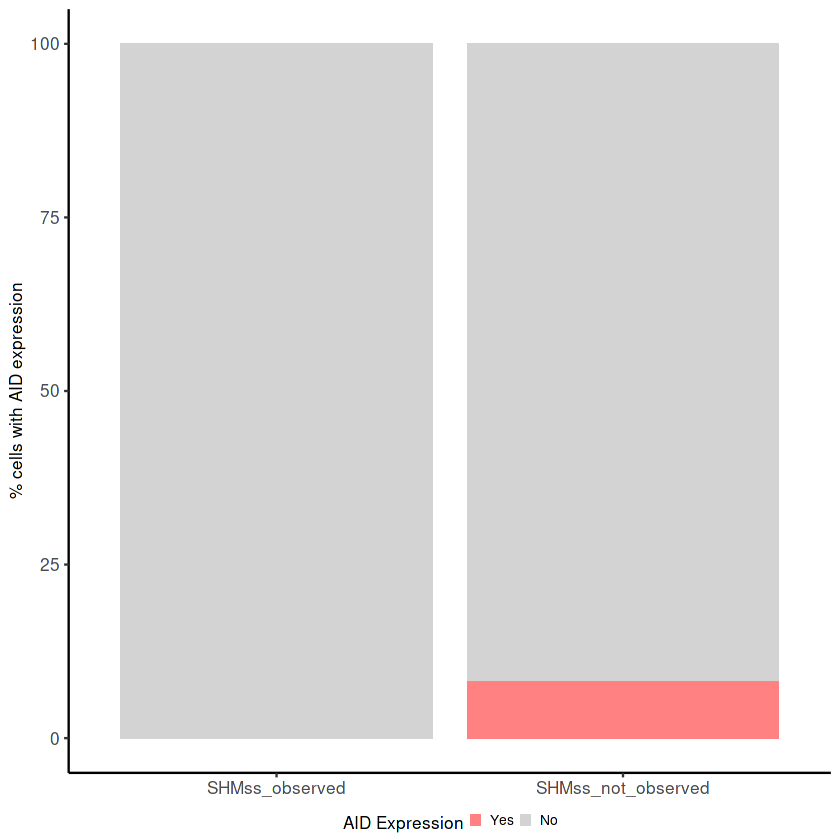

In [154]:
expre_summary <- ggplot(shm_perc %>% filter(gene == "ADAR") %>% group_by(group, expression), aes(x = group, y = perc, fill = expression)) +
  geom_bar(stat = "identity") +
  scale_fill_manual(values = c("#d3d3d3", "#ff8181"), name = "AID Expression", guide = guide_legend(reverse = TRUE)) +
  labs(x = "", y = "% cells with AID expression") +
  theme_classic() +
  scale_x_discrete(labels = c("neg_shm" = "SHMa not observed", "pos_shm" = "SHMa observed")) +
  theme(
    legend.position = "bottom", legend.margin = margin(t = -0.5, unit = "cm"),
    axis.text = element_text(size = 10, angle = 0),
    axis.title = element_text(size = 10),
    legend.title = element_text(size = 10), legend.text = element_text(size = 8), legend.key.size = unit(0.5, "line")
  )


fig_save(expre_summary, filename = "figs/FL/ADAR_expression_summary", formats = c("pdf", "png"), width = 10, height = 15, units = "cm", dpi = 320)
expre_summary

## **Analysis with normalize data**

In [37]:
# filter only the GEX for the list of genes
dd <- CLL_combined_norm@assays$SCT@data %>%
  as.data.frame() %>%
  rownames_to_column(var = "gene") %>%
  filter(gene %in% genes_names$gene) %>%
  column_to_rownames(var = "gene") %>%
  t() %>%
  as.data.frame() %>%
  rownames_to_column(var = "cell")

head(dd)

,cell,RPA2,MUTYH,ADAR,FAM72A,PARP1,MSH2,MSH6,APLF,POLE4,⋯,RPA1,LIG3,PCNA,CHAF1A,XRCC1,LIG1,PNKP,POLD1,CHAF1B,POLE2
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,Q1_AAACCTGAGCGATAGC-1,0,0,0,0,0,0,0,0,0.0000000,⋯,0,0,0.6931472,0,0,0,0.6931472,0,0,0
2,Q1_AAACCTGAGCTAGTGG-1,0,0,0,0,0,0,0,0,0.6931472,⋯,0,0,0.0000000,0,0,0,0.0000000,0,0,0
3,Q1_AAACCTGCAAATACAG-1,0,0,0,0,0,0,0,0,0.0000000,⋯,0,0,0.0000000,0,0,0,0.0000000,0,0,0
4,Q1_AAACCTGCAATTGCTG-1,0,0,0,0,0,0,0,0,0.0000000,⋯,0,0,0.0000000,0,0,0,0.0000000,0,0,0
5,Q1_AAACCTGCATCCTAGA-1,0,0,0,0,0,0,0,0,0.0000000,⋯,0,0,0.0000000,0,0,0,0.0000000,0,0,0
6,Q1_AAACCTGCATGACATC-1,0,0,0,0,0,0,0,0,0.0000000,⋯,0,0,0.0000000,0,0,0,0.0000000,0,0,0


In [38]:
# clean df and include experiment column
pd <- dd %>%
  mutate(experiment = str_sub(cell, 1, 2)) %>% # str_extract("/\/$/", cell
  mutate(cell = gsub("^.{3}|.{2}$", "", cell)) # %>%
#       mutate(UNG_cat=ifelse(UNG == 0, "No", "Yes"))
head(pd)

,cell,RPA2,MUTYH,ADAR,FAM72A,PARP1,MSH2,MSH6,APLF,POLE4,⋯,LIG3,PCNA,CHAF1A,XRCC1,LIG1,PNKP,POLD1,CHAF1B,POLE2,experiment
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
1,AAACCTGAGCGATAGC,0,0,0,0,0,0,0,0,0.0000000,⋯,0,0.6931472,0,0,0,0.6931472,0,0,0,Q1
2,AAACCTGAGCTAGTGG,0,0,0,0,0,0,0,0,0.6931472,⋯,0,0.0000000,0,0,0,0.0000000,0,0,0,Q1
3,AAACCTGCAAATACAG,0,0,0,0,0,0,0,0,0.0000000,⋯,0,0.0000000,0,0,0,0.0000000,0,0,0,Q1
4,AAACCTGCAATTGCTG,0,0,0,0,0,0,0,0,0.0000000,⋯,0,0.0000000,0,0,0,0.0000000,0,0,0,Q1
5,AAACCTGCATCCTAGA,0,0,0,0,0,0,0,0,0.0000000,⋯,0,0.0000000,0,0,0,0.0000000,0,0,0,Q1
6,AAACCTGCATGACATC,0,0,0,0,0,0,0,0,0.0000000,⋯,0,0.0000000,0,0,0,0.0000000,0,0,0,Q1


In [39]:
# merge SHMss and expression data
cell_list <- df_summary %>%
  mutate(
    experiment = str_sub(subject, 1, 2),
    group = "SHMss_observed"
  ) %>%
  select(experiment, cell, group) %>%
  distinct() %>%
  right_join(pd, by = c("cell", "experiment")) %>%
  mutate(group = ifelse(is.na(group), "SHMss_not_observed", "SHMss_observed"))

In [40]:
# remove incomplete cells and possible false positives
false_positives <- df %>%
  mutate(experiment = str_sub(subject, 1, 2), group = "SHMss_not_observed") %>%
  select(experiment, cell, group) %>%
  distinct()

cell_list <- cell_list %>%
  right_join(df_complete_cells) %>%
  anti_join(false_positives)

Joining, by = c("experiment", "cell")
Joining, by = c("experiment", "cell", "group")


### Filter out MBL data

In [41]:
# summarize data
shm_perc_sub <-  cell_list %>% filter(!subject %in% c("S9121","S9534") ) %>%
  gather(-subject, -experiment, -cell, -group, key = "gene", value = "expression") %>%
  mutate(expression_cat = case_when(
     (expression > 0) & (expression < 1)  ~ ">0<1",
     (expression >= 1) & (expression <= 2)  ~ "1-2",
     TRUE ~ as.character(expression))) %>%
  select(-experiment, -cell,-expression) %>%
  group_by( gene, group, expression_cat) %>%
  summarise(count = n(), .groups="drop_last") %>%
  mutate(perc = count / sum(count) * 100) %>%
  left_join(genes_names, by = c("gene")) %>%
  mutate(group = factor(group, levels = c("SHMss_observed", "SHMss_not_observed"))) %>%
  arrange( gene, group)

In [42]:
write.csv(shm_perc_sub, "output/shm_perc_sub_norm_CLL.csv", row.names=FALSE)

### DNA repair genes expression analysis

In [43]:
#define gene order for plotting
gene_order <- shm_perc_sub %>% filter(group == "SHMss_not_observed", expression_cat == "0") %>% arrange(-perc) %>% pull(gene) %>% unique()
gene_order

[1] "CHAF1B" "FAM72A" "MLH1"   "MSH2"   "MSH6"   "NEIL1"  "NEIL2"  "PARP2" 
 [9] "PCNA"   "POLE"   "POLE2"  "RPA4"   "LIG1"   "LIG3"   "MLH3"   "MSH3"  
[17] "MSH5"   "NTHL1"  "OGG1"   "RFC3"   "RFC5"   "APLF"   "APTX"   "FEN1"  
[25] "POLB"   "POLD1"  "UNG"    "XRCC1"  "APEX2"  "MUTYH"  "POLD3"  "POLL"  
[33] "RFC2"   "CHAF1A" "PARP4"  "PNKP"   "TDG"    "RPA1"   "SMUG1"  "PARP3" 
[41] "PMS1"   "POLD2"  "RECQL"  "RFC4"   "POLE3"  "RPA2"   "NUDT1"  "PMS2"  
[49] "ADAR"   "RFC1"   "APEX1"  "RPA3"   "PARP1"  "HMGB2"  "POLE4"  "MBD4"  
[57] "MPG"    "HMGB1"  "POLD4"

In [44]:
# change name of pathway
pathway.labs <- c('','BER','BER/MMR','MMR')
names(pathway.labs) <- c('SHM','BER','BER/MMR','MMR')

# change name of group
group.labs <- c("SHMss observed","SHMss not observed")
names(group.labs) <- c("SHMss_observed","SHMss_not_observed")

In [45]:
shm_perc_pub <- shm_perc_sub %>% 
                 mutate(gene = factor(gene, levels = gene_order))  %>% 
                 filter(!gene %in% c("ADAR")) %>% 
                 mutate(pathway = factor(pathway, levels = c('SHM','BER','MMR','BER/MMR'))) %>% 
                  mutate(expression_cat = factor(expression_cat, levels = c('0','>0<1','1-2'))) 
#                 mutate(expression = case_when(
#     (gene == "AICDA") & (expression == "No") ~ "F",
#     (gene == "AICDA") & (expression == "Yes") ~ "T",
#     TRUE ~ expression))

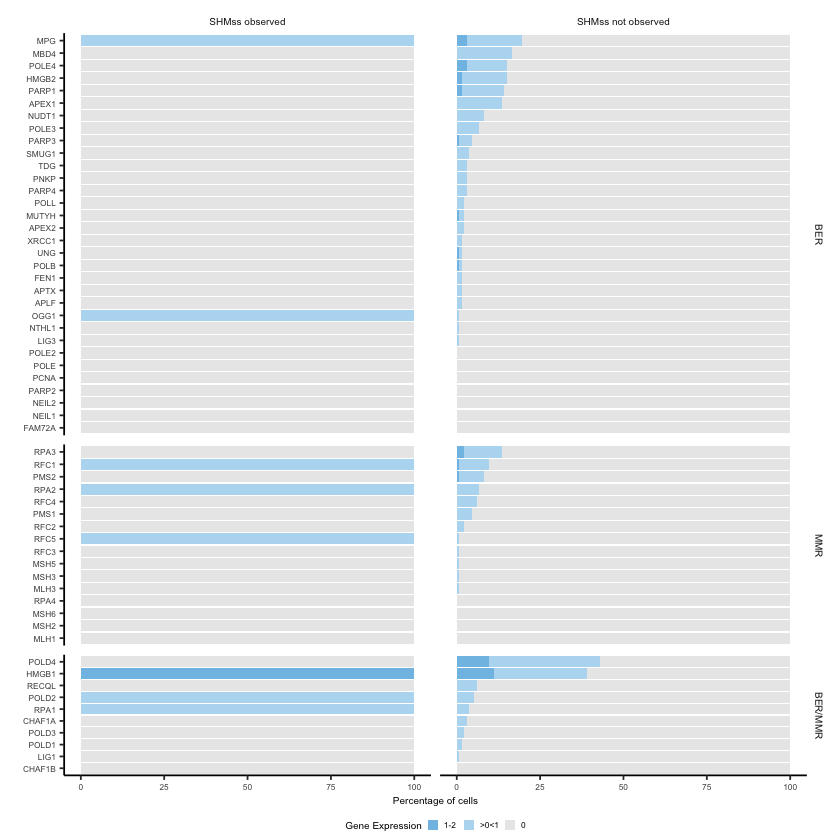

In [46]:
expre_summary <- ggplot(shm_perc_pub  %>% filter(!is.na(gene)), aes(x = gene, y = perc, fill = expression_cat)) +
  geom_bar(stat = "identity") +
#  scale_fill_manual(values = c("#d3d3d3","#B4617A","#1c9262","#384abd","#4aa5dc","#a09ece"), name = "Gene Expression", guide = guide_legend(reverse = TRUE)) +
  scale_fill_manual(values = c("#e9e9e9","#b6dbf1","#80c0e6","#4aa5dc","#384abd","#273384"), name = "Gene Expression", guide = guide_legend(reverse = TRUE)) +

  labs(x = "", y = "Percentage of cells") +
  theme_classic() +
  scale_x_discrete(labels = c("neg_shm" = "SHMa not observed", "pos_shm" = "SHMa observed")) +
  theme(
    legend.position = "bottom", legend.margin = margin(t = -0.1, unit = "cm"),
    axis.text = element_text(size = 5, angle = 0),
    axis.title = element_text(size = 6),
    legend.title = element_text(size = 6), legend.text = element_text(size = 5), legend.key.size = unit(0.5, "line"),
    strip.text.x = element_text(size = 6),strip.text.y = element_text(size = 6), strip.background = element_blank()) +
  facet_grid(pathway ~ group, scales = "free", space = "free", labeller = labeller(group = group.labs)) +  #labeller = labeller(pathway = pathway.labs
  force_panelsizes(rows = c(1,0.5,0.3)) +
  coord_flip() #+
#  scale_x_discrete(expand = c(1, 0.5,0,0)) +



fig_save(expre_summary, filename = "figs/FL/DNA_repair_expresion_norm", formats = c("pdf", "png"), width = 7, height = 12, units = "cm", dpi = 320)
expre_summary

In [47]:
shm_perc_pub_merge <- shm_perc_pub  %>% filter(!is.na(gene) , group == "SHMss_not_observed") %>%
mutate(diagnosis="CLL") 

write.csv(shm_perc_pub_merge, "output/shm_perc_sub_CLL_norm_v1.csv", row.names=FALSE)